In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

sns.set(style="whitegrid")


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uncleaned_DS_jobs.csv')
display(df.head())

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [4]:
sorted(df['Job Title'].unique())


['(Sr.) Data Scientist -',
 'AI Data Scientist',
 'AI Ops Data Scientist',
 'AI/ML - Machine Learning Scientist, Siri Understanding',
 'Analytics - Business Assurance Data Analyst',
 'Analytics Manager',
 'Analytics Manager - Data Mart',
 'Applied AI Scientist / Engineer',
 'Applied Computer Scientist',
 'Applied Technology Researcher / Data Scientist',
 'Associate Data Scientist',
 'Aviation AI/ML Data Scientist',
 'Big Data Engineer',
 'Business Data Analyst',
 'Business Intelligence Analyst',
 'Business Intelligence Analyst I- Data Insights',
 'COMPUTER SCIENTIST - ENGINEER - RESEARCH COMPUTER SCIENTIST - SIGNAL PROCESSING',
 'COMPUTER SCIENTIST - ENGINEER - RESEARCH COMPUTER SCIENTIST - TRANSPORTATION TECHNOLOGY',
 'Chief Scientist',
 'Clinical Data Analyst',
 'Cloud Data Engineer (Azure)',
 'Computational Behavioral Scientist',
 'Computational Scientist',
 'Computational Scientist, Machine Learning',
 'Computer Scientist 1',
 'Computer Vision / Deep Learning Scientist',
 'Data & M

In [5]:
def job_title(title):
    title_lower = title.lower()
    if 'data scientist' in title_lower:
        return 'Data scientist'
    elif 'data engineer' in title_lower:
        return 'Data engineer'
    elif 'analyst' in title_lower:
        return 'Analyst'
    elif 'machine learning' in title_lower:
        return 'Machine Learning Engineer'
    elif 'manager' in title_lower:
        return 'Manager'
    elif 'director' in title_lower:
        return 'Director'
    return 'NA'

df['Updated Job Title'] = df['Job Title'].apply(job_title)
df['Updated Job Title'].value_counts()

,count
Updated Job Title,
Data scientist,455
NA,69
Analyst,55
Data engineer,47
Machine Learning Engineer,36
Manager,7
Director,3


In [6]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Updated Job Title
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",Data scientist
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,Data scientist
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,Data scientist
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",Data scientist
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",Data scientist


In [7]:
import numpy as np

# Identify non-standard missing value representations
missing_value_indicators = ['-1', 'Unknown / Non-Applicable']

# Rating is a float column, so the string '-1' above never matches its
# numeric -1.0 placeholder — handle it explicitly here first.
df['Rating'] = df['Rating'].replace(-1, np.nan)

# Replace these indicators with np.nan across the entire DataFrame
df.replace(missing_value_indicators, np.nan, inplace=True)

In [8]:
# Display the number of missing values per column after replacement
print("Number of missing values per column after replacement:")
display(df.isnull().sum().sort_values(ascending=False))

Number of missing values per column after replacement:


,0
Competitors,501
Revenue,240
Sector,71
Industry,71
Rating,50
Headquarters,31
Type of ownership,27
Size,27
Location,0
Company Name,0


## Fixing Duplicate Check

The initial duplicate check (`df.duplicated()`) was flawed because the CSV was loaded with an implicit index column, making every row appear unique. To correctly identify duplicate entries, we need to exclude this 'index' column from the DataFrame before checking for duplicates. This ensures that the comparison is based solely on the actual data content, not the artificial row identifier from the original CSV.

In [9]:
duplicate_rows = df[df.drop(columns=['index']).duplicated()]
print(f"Number of duplicate rows found: {duplicate_rows.shape[0]}")
display(duplicate_rows)

Number of duplicate rows found: 13


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Updated Job Title
135,135,Machine Learning Engineer,$90K-$109K (Glassdoor est.),Role Description\nTriplebyte screens and evalu...,3.2,Triplebyte\n3.2,Remote,"San Francisco, CA",51 to 200 employees,2015,Company - Private,Computer Hardware & Software,Information Technology,NaN,NaN,Machine Learning Engineer
136,136,Senior Data Engineer,$90K-$109K (Glassdoor est.),Lendio is looking to fill a position for a Sen...,4.9,Lendio\n4.9,"Lehi, UT","Lehi, UT",201 to 500 employees,2011,Company - Private,Lending,Finance,$50 to $100 million (USD),NaN,Data engineer
358,358,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
359,359,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
360,360,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
361,361,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
362,362,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
389,389,Data Scientist,$110K-$163K (Glassdoor est.),"Job Description\nAs a Data Scientist, you will...",NaN,HireAi,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
496,496,Data Scientist,$95K-$119K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist
497,497,Data Scientist,$95K-$119K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,NaN,Hatch Data Inc,"San Francisco, CA",NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,Data scientist


## Auditing the 'Industry' Column

Before cleaning or categorizing the 'Industry' column, it's essential to understand its current state. This step involves checking the number of unique industry values, identifying any missing values, and listing all distinct entries to get a comprehensive overview. This helps in planning the categorization strategy.

In [10]:
print(f"Number of unique industries: {df['Industry'].nunique()}")
print(f"Missing values in 'Industry': {df['Industry'].isnull().sum()}")
print("Sorted unique industries:")
# Convert unique values to string before sorting to handle mixed types (str and float for NaN)
unique_industries_str = [str(x) for x in df['Industry'].unique()]
print(sorted(unique_industries_str))

Number of unique industries: 57
Missing values in 'Industry': 71
Sorted unique industries:
['Accounting', 'Advertising & Marketing', 'Aerospace & Defense', 'Architectural & Engineering Services', 'Banks & Credit Unions', 'Biotech & Pharmaceuticals', 'Cable, Internet & Telephone Providers', 'Chemical Manufacturing', 'Colleges & Universities', 'Computer Hardware & Software', 'Construction', 'Consulting', 'Consumer Electronics & Appliances Stores', 'Consumer Products Manufacturing', 'Department, Clothing, & Shoe Stores', 'Electrical & Electronic Manufacturing', 'Energy', 'Enterprise Software & Network Solutions', 'Express Delivery Services', 'Farm Support Services', 'Federal Agencies', 'Financial Transaction Processing', 'Food & Beverage Manufacturing', 'Food & Beverage Stores', 'Health Care Services & Hospitals', 'Health, Beauty, & Fitness', 'Hotels, Motels, & Resorts', 'IT Services', 'Industrial Manufacturing', 'Insurance Agencies & Brokerages', 'Insurance Carriers', 'Internet', 'Invest

## Imputing Missing 'Rating' Values by Industry

To handle missing values in the 'Rating' column, we will impute them using the mean rating specific to each 'Industry'. This approach is more accurate than using a global mean, as different industries might have varying rating standards or distributions. By grouping by industry, we ensure that the imputed values are more contextually relevant. After imputation, we'll check if any ratings are still missing (e.g., for industries that had no ratings at all).

In [11]:
# Fill missing 'Rating' values with the mean rating for each 'Industry'
df['Rating'] = df.groupby('Industry')['Rating'].transform(lambda x: x.fillna(x.mean()))

# Count how many rows still have missing ratings
missing_ratings_after_imputation = df['Rating'].isnull().sum()
print(f"Number of rows with missing 'Rating' after industry-grouped imputation: {missing_ratings_after_imputation}")

Number of rows with missing 'Rating' after industry-grouped imputation: 71


In [12]:

df['Salary Estimate'] = df['Salary Estimate'].apply(
    lambda x: x.replace('(Employer est.)', '')
               .replace(' (Glassdoor est.)', '')
               .replace('$', '')
               .replace('K', '')
)

## Splitting 'Salary Estimate' into Numeric Columns

The 'Salary Estimate' column is currently a string representing a salary range (e.g., "137000-171000"). To enable numerical analysis, we need to convert this into distinct numeric columns for the minimum salary, maximum salary, and their average. Directly computing an average from a text range is not reliable, so this step ensures that we have quantifiable metrics for salary. The `salary_estimate` function already cleaned the format to '137000-171000', so we can now split this string.

In [13]:
# Split 'Salary Estimate' into Min and Max Salary columns (values are in thousands, so multiply by 1000)
df[['Min Salary', 'Max Salary']] = (
    df['Salary Estimate'].str.split('-', expand=True).astype(float) * 1000
)

# Calculate the Average Salary
df['Average Salary'] = (df['Min Salary'] + df['Max Salary']) / 2

print("New salary columns created:")
display(df[['Min Salary', 'Max Salary', 'Average Salary']].head())

New salary columns created:


,Min Salary,Max Salary,Average Salary
0,137000.0,171000.0,154000.0
1,137000.0,171000.0,154000.0
2,137000.0,171000.0,154000.0
3,137000.0,171000.0,154000.0
4,137000.0,171000.0,154000.0


## Categorizing 'Industry' for Better Analysis

With 57 unique industry values, direct analysis can be unwieldy. To simplify and consolidate, we'll create a new `Industry Category` column by mapping these diverse industries into a smaller set of broad, meaningful categories. This categorization uses an explicit Python function, similar to the `job_title` function, ensuring transparency and allowing for easy review and modification of the grouping logic. This design choice avoids 'black-box' categorization and makes the mapping understandable.


## Re-running Duplicate Check After Cleaning

After performing several cleaning and normalization steps on columns like 'Salary Estimate' and creating 'Industry Category', it's important to re-run the duplicate check. This is because two rows that appeared distinct due to minor variations before cleaning (e.g., slightly different salary string formats or industry spellings) might now become identical after their data has been standardized. A second check ensures that all true duplicates are captured post-normalization.

In [14]:
# Decision: dropping the 13 confirmed duplicate rows, since they represent
# the same job posting recorded more than once and would otherwise
# double-count in our salary/rating averages.
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'index'])
print(f"Row count after dropping duplicates: {df.shape[0]}")

Row count after dropping duplicates: 659


In [15]:
duplicate_rows_after_cleaning = df[df.drop(columns=['index']).duplicated()]
print(f"Number of duplicate rows found after cleaning: {duplicate_rows_after_cleaning.shape[0]}")
display(duplicate_rows_after_cleaning)

Number of duplicate rows found after cleaning: 0


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Updated Job Title,Min Salary,Max Salary,Average Salary


## Analyzing Industry Categories: Average Salary, Rating, and Job Postings

This final analysis step groups the data by the newly created 'Industry Category' to derive key insights. For each category, we calculate the average salary, average rating, and the total number of job postings. To ensure the reliability of these averages, we filter out categories that have fewer than 5 job postings. Categories with very few postings might present skewed or unrepresentative averages. The results are then sorted by average salary in descending order, showing the top 5 categories by compensation.

In [16]:
def industry_category(industry):
    if pd.isna(industry):
        return 'Other/Unknown'
    industry_lower = industry.lower()
    if 'finance' in industry_lower or 'insurance' in industry_lower or 'banking' in industry_lower \
       or 'bank' in industry_lower or 'lending' in industry_lower or 'accounting' in industry_lower \
       or 'venture capital' in industry_lower or 'private equity' in industry_lower \
       or 'financial transaction' in industry_lower:
        return 'Finance & Insurance'
    elif 'health' in industry_lower or 'hospital' in industry_lower or 'pharmaceutical' in industry_lower or 'biotech' in industry_lower:
        return 'Healthcare & Biotech'
    elif 'information technology' in industry_lower or 'software' in industry_lower or 'internet' in industry_lower \
         or 'computer' in industry_lower or 'it services' in industry_lower:
        return 'Information Technology'
    elif 'business services' in industry_lower or 'consulting' in industry_lower or 'marketing' in industry_lower \
         or 'advertising' in industry_lower or 'staffing' in industry_lower or 'outsourcing' in industry_lower \
         or 'research & development' in industry_lower or 'research and development' in industry_lower:
        return 'Business & Consulting Services'
    elif 'manufacturing' in industry_lower or 'aerospace' in industry_lower or 'automotive' in industry_lower:
        return 'Manufacturing'
    elif 'education' in industry_lower or 'government' in industry_lower or 'nonprofit' in industry_lower \
         or 'federal agencies' in industry_lower or 'state & regional agencies' in industry_lower \
         or 'colleges & universities' in industry_lower or 'social assistance' in industry_lower:
        return 'Education & Public Sector'
    elif 'retail' in industry_lower or 'consumer' in industry_lower or 'food' in industry_lower \
         or 'wholesale' in industry_lower or 'stores' in industry_lower:
        return 'Retail & Consumer Goods'
    elif 'construction' in industry_lower or 'real estate' in industry_lower or 'engineering services' in industry_lower:
        return 'Construction & Real Estate'
    elif 'transportation' in industry_lower or 'logistics' in industry_lower or 'shipping' in industry_lower \
         or 'rail' in industry_lower or 'delivery' in industry_lower:
        return 'Transportation & Logistics'
    elif 'media' in industry_lower or 'entertainment' in industry_lower or 'video games' in industry_lower \
         or 'publishing' in industry_lower or 'news' in industry_lower:
        return 'Media & Entertainment'
    elif 'energy' in industry_lower or 'oil' in industry_lower or 'gas' in industry_lower or 'utilities' in industry_lower:
        return 'Energy & Utilities'
    elif 'telecommunications' in industry_lower or 'cable' in industry_lower:
        return 'Telecommunications'
    return 'Other/Unknown'

In [17]:
df['Industry Category'] = df['Industry'].apply(industry_category)
print("Industry Category re-applied with updated keyword logic.")

Industry Category re-applied with updated keyword logic.


In [18]:
sorted(df['Updated Job Title'].unique())

['Analyst',
 'Data engineer',
 'Data scientist',
 'Director',
 'Machine Learning Engineer',
 'Manager',
 'NA']

In [19]:
uncategorized = df[df['Industry Category'] == 'Other/Unknown']['Industry'].value_counts()
print(f"Total uncategorized rows: {uncategorized.sum()}")
display(uncategorized)

Total uncategorized rows: 6


,count
Industry,
Timber Operations,2
Travel Agencies,2
"Hotels, Motels, & Resorts",1
Farm Support Services,1


In [20]:
sorted(df['Salary Estimate'].unique())

['101-165',
 '105-167',
 '110-163',
 '112-116',
 '122-146',
 '124-198',
 '128-201',
 '137-171',
 '138-158',
 '141-225',
 '145-225',
 '212-331',
 '31-56',
 '56-97',
 '66-112',
 '69-116',
 '71-123',
 '75-131',
 '79-106',
 '79-131',
 '79-133',
 '79-147',
 '80-132',
 '87-141',
 '90-109',
 '90-124',
 '91-150',
 '92-155',
 '95-119',
 '99-132']

In [21]:
ds_only = df[df['Updated Job Title'] == 'Data scientist']
print(f"Data Scientist-titled postings: {len(ds_only)}")

Data Scientist-titled postings: 444


In [22]:
industry_analysis = ds_only.groupby('Industry Category').agg(
    Average_Salary=('Average Salary', 'mean'),
    Average_Rating=('Rating', 'mean'),
    Posting_Count=('Job Title', 'count')
).reset_index()

industry_analysis_filtered = industry_analysis[industry_analysis['Posting_Count'] >= 5]
industry_analysis_sorted = industry_analysis_filtered[
    industry_analysis_filtered['Industry Category'] != 'Other/Unknown'
].sort_values(by='Average_Salary', ascending=False)

print("Top 5 Industry Categories by Average Salary (Data Scientists only, min 5 postings):")
display(industry_analysis_sorted.head(5))

Top 5 Industry Categories by Average Salary (Data Scientists only, min 5 postings):


,Industry Category,Average_Salary,Average_Rating,Posting_Count
10,Retail & Consumer Goods,158200.000000,3.310000,10
7,Manufacturing,135636.363636,3.615909,44
2,Education & Public Sector,131307.692308,3.815385,13
0,Business & Consulting Services,128403.614458,3.970348,83
5,Healthcare & Biotech,125232.558140,3.665581,43


## Visualizing Industry Categories: Rating vs. Salary by Job Count

This scatter plot visualizes the relationship between the `Average_Rating` (y-axis) and `Average_Salary` (x-axis) for each `Industry Category`. The `Posting_Count` for each category is represented by the size of the bubbles, providing an additional dimension to the analysis. This helps in identifying industry categories that offer competitive salaries and high ratings, while also indicating the volume of job postings.

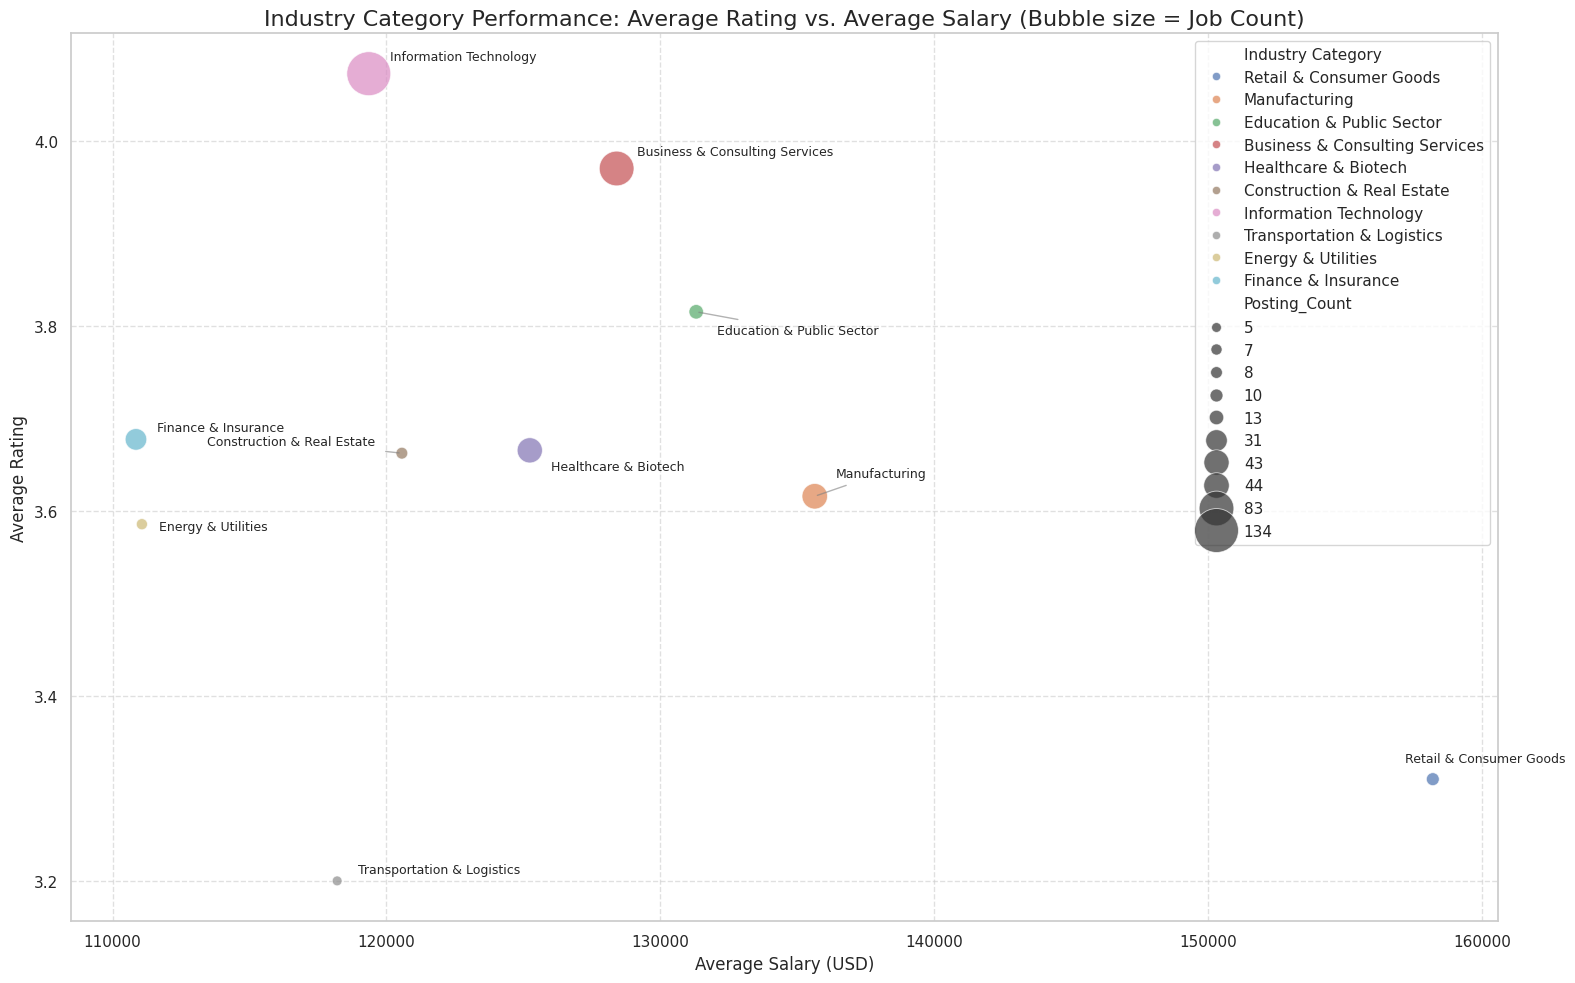

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
scatter = sns.scatterplot(
    x='Average_Salary',
    y='Average_Rating',
    size='Posting_Count',
    sizes=(50, 1000),
    hue='Industry Category',
    data=industry_analysis_sorted,
    legend='full',
    alpha=0.7
)

# Manual label offsets, in points (dx, dy) from each point's center.
label_offsets = {
    'Retail & Consumer Goods':       (-20, 12),
    'Media & Entertainment':         (-15, 10),
    'Manufacturing':                 (15, 14),
    'Business & Consulting Services':(15, 10),
    'Education & Public Sector':     (15, -16),
    'Healthcare & Biotech':          (15, -14),
    'Construction & Real Estate':    (-140, 6),
    'Information Technology':        (15, 10),
    'Telecommunications':            (-15, -18),
    'Transportation & Logistics':    (15, 6),
    'Finance & Insurance':           (15, 6),
    'Energy & Utilities':            (12, -4),
}

# Only these three get a connector line back — everyone else stays clean.
labels_with_lines = {'Manufacturing', 'Education & Public Sector', 'Construction & Real Estate'}

for _, row in industry_analysis_sorted.iterrows():
    label = row['Industry Category']
    dx, dy = label_offsets.get(label, (10, 10))
    arrow_kwargs = {}
    if label in labels_with_lines:
        arrow_kwargs['arrowprops'] = dict(arrowstyle='-', color='gray', alpha=0.6, shrinkA=5)
    plt.annotate(
        label,
        xy=(row['Average_Salary'], row['Average_Rating']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        **arrow_kwargs,
    )

plt.title('Industry Category Performance: Average Rating vs. Average Salary (Bubble size = Job Count)', fontsize=16)
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Top 5 highest-paying industries with more than 10 postings:


,Industry Category,Average_Salary,Average_Rating,Posting_Count,Salary Rank
0,Manufacturing,135636.363636,3.615909,44,1
1,Education & Public Sector,131307.692308,3.815385,13,2
2,Business & Consulting Services,128403.614458,3.970348,83,3
3,Healthcare & Biotech,125232.558140,3.665581,43,4
4,Information Technology,119354.477612,4.072859,134,5


/tmp/ipykernel_56439/874666024.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Industry Category', y='Average_Rating', data=top_10_plus_postings, palette='viridis')


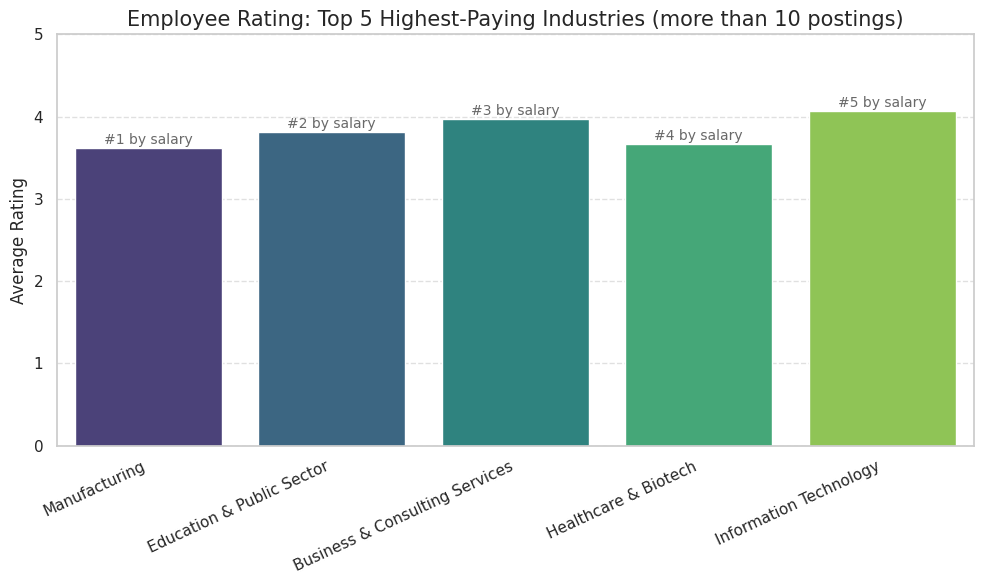

In [24]:
top_10_plus_postings = industry_analysis[
    (industry_analysis['Posting_Count'] > 10) &
    (industry_analysis['Industry Category'] != 'Other/Unknown')
].sort_values(by='Average_Salary', ascending=False).head(5).reset_index(drop=True)

top_10_plus_postings['Salary Rank'] = top_10_plus_postings.index + 1

print("Top 5 highest-paying industries with more than 10 postings:")
display(top_10_plus_postings)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Industry Category', y='Average_Rating', data=top_10_plus_postings, palette='viridis')

for i, row in top_10_plus_postings.iterrows():
    ax.text(
        i, row['Average_Rating'] + 0.05,
        f"#{row['Salary Rank']} by salary",
        ha='center', fontsize=10, color='dimgray'
    )

plt.title('Employee Rating: Top 5 Highest-Paying Industries (more than 10 postings)', fontsize=15)
plt.xlabel('')
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [25]:
!pip install adjustText

### Adjusting the Scatter Plot with Category Labels

I have now installed the `adjustText` library, which will help us place text labels for each industry category on the scatter plot without them overlapping. This will make it easier to identify each data point directly on the plot.

In [26]:
print(f"Rows with missing Industry: {df['Industry'].isnull().sum()}")
print(f"Rows in 'Other/Unknown' bucket: {(df['Industry Category'] == 'Other/Unknown').sum()}")

Rows with missing Industry: 60
Rows in 'Other/Unknown' bucket: 66


In [27]:
output_path = '/content/drive/MyDrive/Colab Notebooks/Uncleaned_DS_jobs_v2.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: /content/drive/MyDrive/Colab Notebooks/Uncleaned_DS_jobs_v2.csv
